# Upscaling a Hollow Casing to a Larger Solid Cylinder

In practice the grid cell used to represent a well casing is often larger
than the physical casing itself.  Here we study the upscaling problem where
the equivalent solid cylinder has an outer radius **b_eff = 2·b**, twice the
true casing outer radius.

Because the model cylinder extends beyond the physical casing, the impedance
used as data must also be evaluated at **r = b_eff = 2·b** — the outer surface
of the upscaling volume.  We compute this by propagating the hollow-casing
surface impedance outward through the background medium using
`propagate_impedance_outward`.

The workflow is:
1. Compute the true hollow-casing impedance at r = b
2. Propagate it outward to r = 2b through the background medium
3. Invert for (σ_eff, μ_r_eff) using a solid-cylinder model of radius 2b
4. Compare with the standard upscaling at radius b
5. Sweep over background conductivity to see its effect on the overshoot

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.constants import mu_0

from thin_sheet import (
    impedance_hollow_cyl,
    impedance_solid_cyl,
    impedance_solid_cyl_dsigma, impedance_solid_cyl_dmu,
    propagate_impedance_outward,
    solve_sigma_mu_eff_one_freq_solid_cyl,
    invert_sigma_mu_eff_vs_freq_solid_cyl,
)

## Parameters

In [23]:
# True hollow casing
b      = 0.05    # outer radius of true casing [m]
t      = 0.025   # wall thickness [m]
a      = b - t   # inner radius [m]
sigma_cas = 1e6  # casing conductivity [S/m]
mur_cas   = 1    # casing relative permeability
mu_cas    = mur_cas * mu_0

# Background / bore medium (same on both sides of the casing)
sigma_bg = 1e-3  # background conductivity [S/m]
mu_bg    = mu_0

# Upscaling cylinder radius
scale_factor = 1.0
b_eff = scale_factor * b   # radius of equivalent solid cylinder [m]

# Analytic volume-average estimates for the TRUE casing geometry
sigma_vol = sigma_cas * (b**2 - a**2) / b**2
mur_vol   = mur_cas  * (t / (2*b)) * (3 - t/b)

# Frequency sweep
frequencies = np.logspace(1, 4.5, 5000)  # Hz
omegas = 2 * np.pi * frequencies

print(f'True casing: a={a} m, b={b} m, t={t} m')
print(f'Upscaling cylinder: b_eff={b_eff} m  (scale factor {scale_factor}x)')
print(f'Volume-average sigma: {sigma_vol:.3e} S/m  (frac = {(b**2-a**2)/b**2:.3f})')
print(f'Volume-average mur:   {mur_vol:.3f}')

True casing: a=0.025 m, b=0.05 m, t=0.025 m
Upscaling cylinder: b_eff=0.05 m  (scale factor 1.0x)
Volume-average sigma: 7.500e+05 S/m  (frac = 0.750)
Volume-average mur:   0.625


## 1. Forward Model: True Impedance at r = b_eff

Step 1 — impedance of the hollow casing at its outer surface r = b.
Step 2 — propagate outward through background medium to r = b_eff = 2b.

In [24]:
# True hollow-casing impedance at r = b
Z_casing = impedance_hollow_cyl(
    omegas, a, b,
    mu_bg, sigma_bg,    # bore medium
    mu_cas, sigma_cas,  # casing material
)

# Propagate to r = b_eff through background medium
Z_data = propagate_impedance_outward(
    omegas, b, b_eff, Z_casing, mu_bg, sigma_bg
)

# For reference: impedance of the background medium alone at r = b_eff
# (what you would see without any casing)
Z_bg_only = propagate_impedance_outward(
    omegas, b, b_eff,
    impedance_hollow_cyl(omegas, a, b, mu_bg, sigma_bg, mu_bg, sigma_bg),
    mu_bg, sigma_bg
)

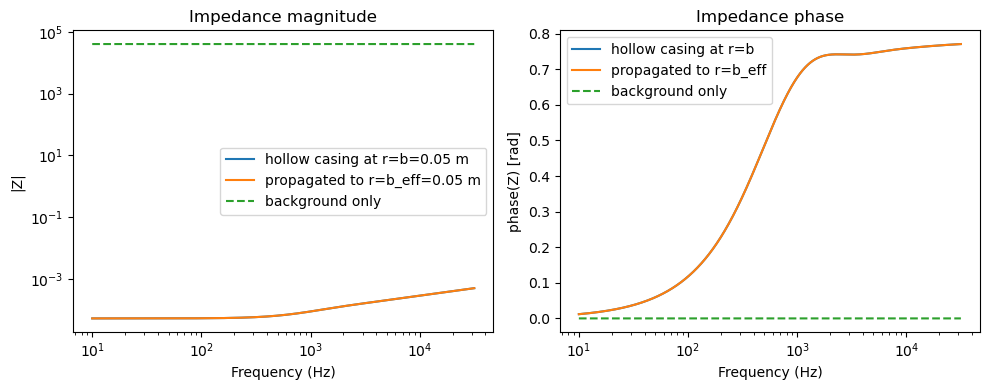

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].loglog(frequencies, np.abs(Z_casing), label=f'hollow casing at r=b={b} m')
ax[0].loglog(frequencies, np.abs(Z_data),   label=f'propagated to r=b_eff={b_eff} m')
ax[0].loglog(frequencies, np.abs(Z_bg_only), ls='--', label='background only')
ax[0].set_xlabel('Frequency (Hz)'); ax[0].set_ylabel('|Z|')
ax[0].set_title('Impedance magnitude'); ax[0].legend()

ax[1].semilogx(frequencies, np.angle(Z_casing), label=f'hollow casing at r=b')
ax[1].semilogx(frequencies, np.angle(Z_data),   label=f'propagated to r=b_eff')
ax[1].semilogx(frequencies, np.angle(Z_bg_only), ls='--', label='background only')
ax[1].set_xlabel('Frequency (Hz)'); ax[1].set_ylabel('phase(Z) [rad]')
ax[1].set_title('Impedance phase'); ax[1].legend()

plt.tight_layout()

## 2. Inversion: σ_eff and μ_r_eff for Solid Cylinder of Radius b_eff

We invert for real-valued (σ_eff, μ_r_eff) such that
`impedance_solid_cyl(ω, b_eff, μ_eff, σ_eff)` matches `Z_data` at every frequency.

In [ ]:
# Physical bounds and initial guess (used throughout this notebook)
sigma_init_large = sigma_cas * (b**2 - a**2) / b_eff**2
bounds_real = ([0, 0], [2 * sigma_cas, 100 * mu_0])

# Derivative test at one frequency
ind = 100
sh, mh, zp, ok_one, msg = solve_sigma_mu_eff_one_freq_solid_cyl(
    omegas[ind], Z_data[ind], b=b_eff,
    sigma0=sigma_init_large + 0j,
    mu0=mu_0 + 0j,
    complex_values=False,
    test=True,
)
print(f'ok={ok_one}  sigma_hat={sh:.4e}  mu_r_hat={mh.real/mu_0:.4f}')

==================== check_derivative ====================
iter    h         |ft-f0|   |ft-f0-h*J0*dx|  Order
---------------------------------------------------------
 0   1.00e-01    1.245e-05     9.747e-07      nan
 1   1.00e-02    1.254e-06     9.836e-09      1.996
 2   1.00e-03    1.255e-07     9.838e-11      2.000
 3   1.00e-04    1.255e-08     9.839e-13      2.000
 4   1.00e-05    1.255e-09     9.839e-15      2.000
 5   1.00e-06    1.255e-10     9.837e-17      2.000
 6   1.00e-07    1.255e-11     9.669e-19      2.007
========================= PASS! =========================
Well done Lindseyjh!

ok=True  sigma_hat=7.5001e+05+0.0000e+00j  mu_r_hat=0.6414


In [27]:
sigma_eff_large, mu_eff_large, z_fit_large, ok_large = \
    invert_sigma_mu_eff_vs_freq_solid_cyl(
        omegas, Z_data, b=b_eff,
        sigma_init=sigma_init_large + 0j,
        mu_init=mu_0 + 0j,
        complex_values=False,
        bounds=bounds_real,
    )
print(f'Convergence: {ok_large.mean()*100:.1f}%')

Convergence: 100.0%


### 2a. Standard upscaling (b_eff = b) for comparison

Run the same inversion using the true casing radius so we can compare.

In [28]:
sigma_eff_std, mu_eff_std, z_fit_std, ok_std = \
    invert_sigma_mu_eff_vs_freq_solid_cyl(
        omegas, Z_casing, b=b,
        sigma_init=sigma_vol + 0j,
        mu_init=mu_0 + 0j,
        complex_values=False,
        bounds=bounds_real,
    )
print(f'Standard convergence: {ok_std.mean()*100:.1f}%')

Standard convergence: 100.0%


## 3. Results

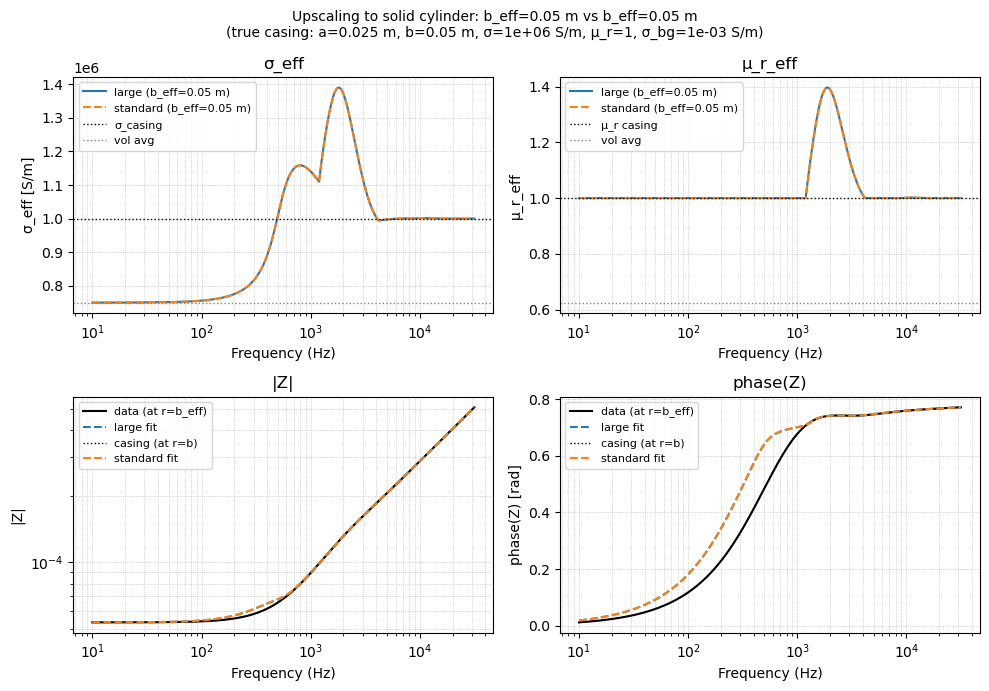

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7))

# ── σ_eff ────────────────────────────────────────────────────────────────
ax[0, 0].semilogx(frequencies[ok_large], sigma_eff_large[ok_large].real,
                  'C0-', label=f'large (b_eff={b_eff} m)')
ax[0, 0].semilogx(frequencies[ok_std],   sigma_eff_std[ok_std].real,
                  'C1--', label=f'standard (b_eff={b} m)')
ax[0, 0].axhline(sigma_cas, ls=':', color='k', lw=1, label='σ_casing')
ax[0, 0].axhline(sigma_vol, ls=':', color='gray', lw=1, label='vol avg')
ax[0, 0].set_title('σ_eff'); ax[0, 0].set_xlabel('Frequency (Hz)')
ax[0, 0].set_ylabel('σ_eff [S/m]'); ax[0, 0].legend(fontsize=8)

# ── μ_r_eff ──────────────────────────────────────────────────────────────
ax[0, 1].semilogx(frequencies[ok_large], mu_eff_large[ok_large].real / mu_0,
                  'C0-', label=f'large (b_eff={b_eff} m)')
ax[0, 1].semilogx(frequencies[ok_std],   mu_eff_std[ok_std].real / mu_0,
                  'C1--', label=f'standard (b_eff={b} m)')
ax[0, 1].axhline(mur_cas, ls=':', color='k', lw=1, label='μ_r casing')
ax[0, 1].axhline(mur_vol, ls=':', color='gray', lw=1, label='vol avg')
ax[0, 1].set_title('μ_r_eff'); ax[0, 1].set_xlabel('Frequency (Hz)')
ax[0, 1].set_ylabel('μ_r_eff'); ax[0, 1].legend(fontsize=8)

# ── |Z| fit quality ──────────────────────────────────────────────────────
ax[1, 0].loglog(frequencies, np.abs(Z_data),         'k-',  lw=1.5, label='data (at r=b_eff)')
ax[1, 0].loglog(frequencies[ok_large], np.abs(z_fit_large[ok_large]),
                'C0--', label='large fit')
ax[1, 0].loglog(frequencies, np.abs(Z_casing),        'k:',  lw=1, label='casing (at r=b)')
ax[1, 0].loglog(frequencies[ok_std],   np.abs(z_fit_std[ok_std]),
                'C1--', label='standard fit')
ax[1, 0].set_title('|Z|'); ax[1, 0].set_xlabel('Frequency (Hz)')
ax[1, 0].set_ylabel('|Z|'); ax[1, 0].legend(fontsize=8)

# ── phase(Z) fit quality ─────────────────────────────────────────────────
ax[1, 1].semilogx(frequencies, np.angle(Z_data),  'k-',  lw=1.5, label='data (at r=b_eff)')
ax[1, 1].semilogx(frequencies[ok_large], np.angle(z_fit_large[ok_large]),
                  'C0--', label='large fit')
ax[1, 1].semilogx(frequencies, np.angle(Z_casing), 'k:',  lw=1, label='casing (at r=b)')
ax[1, 1].semilogx(frequencies[ok_std],   np.angle(z_fit_std[ok_std]),
                  'C1--', label='standard fit')
ax[1, 1].set_title('phase(Z)'); ax[1, 1].set_xlabel('Frequency (Hz)')
ax[1, 1].set_ylabel('phase(Z) [rad]'); ax[1, 1].legend(fontsize=8)

for a_ in ax.flat:
    a_.grid(True, which='both', ls=':', lw=0.5)

fig.suptitle(
    f'Upscaling to solid cylinder: b_eff={b_eff} m vs b_eff={b} m\n'
    f'(true casing: a={a} m, b={b} m, σ={sigma_cas:.0e} S/m, μ_r={mur_cas}, '
    f'σ_bg={sigma_bg:.0e} S/m)',
    fontsize=10
)
plt.tight_layout()

## 4. Effect of Background Conductivity

The background medium fills both the bore and the annulus between the true
casing (r=b) and the upscaling cylinder (r=b_eff).  Varying its conductivity
changes both the forward data Z_data and the propagation step.

In [ ]:
sigma_bg_values = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1e0])

cmap_bg = plt.cm.plasma
norm_bg = mpl.colors.LogNorm(vmin=sigma_bg_values.min(), vmax=sigma_bg_values.max())

results_bg = []
for s_bg in sigma_bg_values:
    # True impedance at r=b
    Z_cas = impedance_hollow_cyl(
        omegas, a, b, mu_bg, s_bg, mu_cas, sigma_cas
    )
    # Propagate to r=b_eff
    Z_d = propagate_impedance_outward(omegas, b, b_eff, Z_cas, mu_bg, s_bg)

    # Invert with bounds
    s_eff, m_eff, z_fit, ok = invert_sigma_mu_eff_vs_freq_solid_cyl(
        omegas, Z_d, b=b_eff,
        sigma_init=sigma_init_large + 0j,
        mu_init=mu_0 + 0j,
        complex_values=False,
        bounds=bounds_real,
    )
    results_bg.append(dict(s_bg=s_bg, Z_d=Z_d, s_eff=s_eff, m_eff=m_eff, z_fit=z_fit, ok=ok))
    print(f'sigma_bg = {s_bg:.1e}  |  convergence: {ok.mean()*100:.0f}%')

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for r in results_bg:
    color = cmap_bg(norm_bg(r['s_bg']))
    ok = r['ok']
    ax[0].semilogx(frequencies[ok], r['s_eff'][ok].real,
                   color=color, label=f"{r['s_bg']:.0e}")
    ax[1].semilogx(frequencies[ok], r['m_eff'][ok].real / mu_0, color=color)

# Reference lines
ax[0].axhline(sigma_cas, ls='--', color='k', lw=1, label='σ_casing')
ax[0].axhline(sigma_vol, ls=':',  color='k', lw=1, label='vol avg')
ax[1].axhline(mur_cas,   ls='--', color='k', lw=1, label='μ_r true')
ax[1].axhline(mur_vol,   ls=':',  color='k', lw=1, label='vol avg')

ax[0].set_title('σ_eff'); ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('σ_eff [S/m]'); ax[0].legend(title='σ_bg (S/m)', fontsize=8)
ax[1].set_title('μ_r_eff'); ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('μ_r_eff'); ax[1].legend(fontsize=8)

for a_ in ax:
    a_.grid(True, which='both', ls=':', lw=0.5)

sm = mpl.cm.ScalarMappable(norm=norm_bg, cmap=cmap_bg)
fig.colorbar(sm, ax=ax, label='σ_background (S/m)')

fig.suptitle(
    f'Effect of background conductivity on upscaled properties\n'
    f'(b_eff={b_eff} m, scale factor {scale_factor}x)',
    fontsize=10
)
plt.tight_layout()

## 5. Effect of Scale Factor

How do the effective properties change as we increase b_eff / b?

In [ ]:
scale_factors = np.array([1.0, 1.5, 2.0, 3.0, 5.0])

cmap_sf = plt.cm.viridis
norm_sf = mpl.colors.Normalize(vmin=scale_factors.min(), vmax=scale_factors.max())

# True casing impedance at r=b (fixed)
Z_cas_ref = impedance_hollow_cyl(
    omegas, a, b, mu_bg, sigma_bg, mu_cas, sigma_cas
)

results_sf = []
for sf in scale_factors:
    b_e = sf * b
    Z_d = propagate_impedance_outward(omegas, b, b_e, Z_cas_ref, mu_bg, sigma_bg)

    # Scale the initial guess and upper bound to match each b_e
    s_init = sigma_cas * (b**2 - a**2) / b_e**2
    bounds_sf = ([0, mu_0], [2 * sigma_cas, 100 * mu_0])

    s_eff, m_eff, z_fit, ok = invert_sigma_mu_eff_vs_freq_solid_cyl(
        omegas, Z_d, b=b_e,
        sigma_init=s_init + 0j,
        mu_init=mu_0 + 0j,
        complex_values=False,
        bounds=bounds_sf,
    )
    results_sf.append(dict(sf=sf, b_e=b_e, s_eff=s_eff, m_eff=m_eff, z_fit=z_fit, ok=ok))
    print(f'scale={sf:.1f}x  b_eff={b_e:.3f} m  |  convergence: {ok.mean()*100:.0f}%')

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

for r in results_sf:
    color = cmap_sf(norm_sf(r['sf']))
    ok = r['ok']
    ax[0].semilogx(frequencies[ok], r['s_eff'][ok].real,
                   color=color, label=f"{r['sf']:.1f}x (b_eff={r['b_e']:.3f} m)")
    ax[1].semilogx(frequencies[ok], r['m_eff'][ok].real / mu_0, color=color)

ax[0].axhline(sigma_cas, ls='--', color='k', lw=1, label='σ_casing')
ax[0].axhline(sigma_vol, ls=':',  color='k', lw=1, label='vol avg')
ax[1].axhline(mur_cas,   ls='--', color='k', lw=1, label='μ_r true')
ax[1].axhline(mur_vol,   ls=':',  color='k', lw=1, label='vol avg')

ax[0].set_title('σ_eff vs scale factor'); ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('σ_eff [S/m]'); ax[0].legend(fontsize=8)
ax[1].set_title('μ_r_eff vs scale factor'); ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('μ_r_eff'); ax[1].legend(fontsize=8)

for a_ in ax:
    a_.grid(True, which='both', ls=':', lw=0.5)

sm = mpl.cm.ScalarMappable(norm=norm_sf, cmap=cmap_sf)
fig.colorbar(sm, ax=ax, label='Scale factor (b_eff / b)')

fig.suptitle(
    f'Effect of upscaling scale factor on effective properties\n'
    f'(true casing: b={b} m, σ_bg={sigma_bg:.0e} S/m)',
    fontsize=10
)
plt.tight_layout()